# Week 4 — Applied Probability & Statistics, and Your First Real Regression Model

**Course context:** Week 3 built the theory (distributions, gradient descent, hypothesis testing in the abstract). This week applies it to real questions: is this distribution skewed, is this difference between groups real, and — the first proper ML model of the course — fitting a linear regression with scikit-learn instead of hand-written NumPy.

**How this notebook is organized:** one section per day, each with: what it covers → why it matters for AI work → code → pitfalls.


## Day 1 — Random Variables, Expectation, and PMF/PDF

**What it covers:** Simulating a random process (dice rolls) to estimate probabilities empirically, and the difference between a discrete random variable (PMF - Probability Mass Function) and a continuous one (PDF - Probability Density Function). Also: expectation (mean) and variance of a random variable, computed directly from its outcomes and probabilities.

**Why it matters for AI work:** "Empirical probability from simulation" is exactly how you'd estimate a model's error rate from a test set, or how Monte Carlo methods work (used in reinforcement learning, Bayesian inference). Expectation and variance are the same formulas used to describe how a model's predictions are distributed.

**When to use what:**
- **PMF** — discrete outcomes (dice roll: 1,2,3,4,5,6 — nothing in between is possible)
- **PDF** — continuous outcomes (height, temperature — any value in a range is possible). Note: a PDF value is NOT a probability by itself (it can exceed 1) — you get probability by finding the *area under the curve* over a range.

**Pitfalls:**
- Simulated ("empirical") probabilities won't exactly match the theoretical value (e.g. `P(even) = 0.5` for a fair die) — they converge as the sample size grows. 10,000 rolls gets close; 10 rolls won't.
- Confusing "probability" with "probability density": a PDF's height at a single point is not a probability — only the *area* under a range of the curve is.


In [1]:
import numpy as np

# Simulating 10,000 dice rolls to estimate probabilities empirically
np.random.seed(0)
rolls = np.random.randint(1, 7, size=10000)

P_even = np.sum(rolls % 2 == 0) / len(rolls)
P_greater_than_4 = np.sum(rolls > 4) / len(rolls)

print("P(Even): ", P_even, " (theoretical: 0.5)")
print("P(Greater than 4): ", P_greater_than_4, " (theoretical: 0.333)")

P(Even):  0.5085  (theoretical: 0.5)
P(Greater than 4):  0.331  (theoretical: 0.333)


In [2]:
# Expectation and variance of a discrete random variable, computed directly
outcomes = np.array([1, 2, 3, 4, 5, 6])
probabilities = np.array([1 / 6] * 6)

expectation = np.sum(outcomes * probabilities)
print("Expectation (Mean):", expectation)

variance = np.sum((outcomes - expectation) ** 2 * probabilities)
std_dev = np.sqrt(variance)
print("Variance:", variance)
print("Standard Deviation:", std_dev)

Expectation (Mean): 3.5
Variance: 2.9166666666666665
Standard Deviation: 1.707825127659933


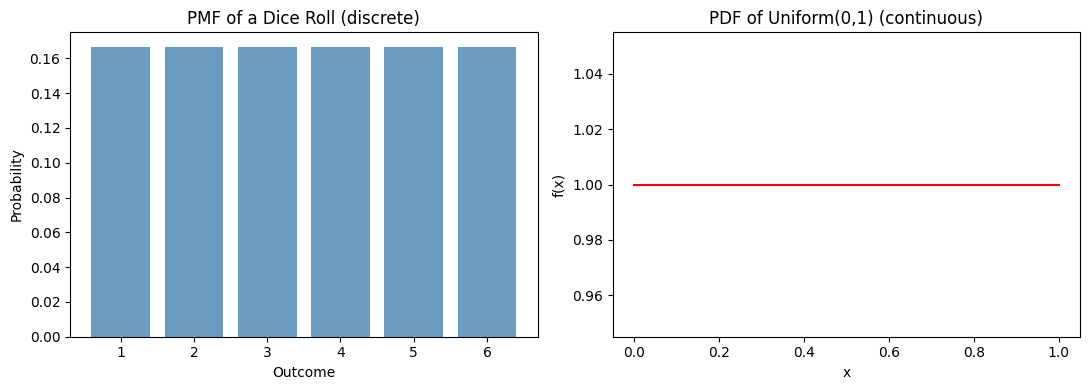

In [3]:
import matplotlib.pyplot as plt
from scipy.stats import uniform

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# PMF: discrete random variable (dice roll)
axes[0].bar(outcomes, probabilities, color="steelblue", alpha=0.8)
axes[0].set_title("PMF of a Dice Roll (discrete)")
axes[0].set_xlabel("Outcome")
axes[0].set_ylabel("Probability")

# PDF: continuous random variable (uniform between 0 and 1)
x = np.linspace(0, 1, 100)
pdf = uniform.pdf(x, loc=0, scale=1)
axes[1].plot(x, pdf, color="red")
axes[1].set_title("PDF of Uniform(0,1) (continuous)")
axes[1].set_xlabel("x")
axes[1].set_ylabel("f(x)")

plt.tight_layout()
plt.show()

## Day 2 — Shape of a Distribution: Skewness and Kurtosis

**What it covers:** Skewness (asymmetry of a distribution) and kurtosis (how heavy the "tails" are compared to a normal distribution), applied to a real dataset (Iris).

**Why it matters for AI work:** Many ML algorithms (especially linear models) perform better when features are roughly symmetric/normal. Detecting skew early tells you whether you need a transformation (log, square root) before modeling — skipping this is a common reason simple models underperform on real data.

**When to use what:**
- `skew() > 0` — right-skewed (long tail toward high values, e.g. income data)
- `skew() < 0` — left-skewed (long tail toward low values)
- `skew() ≈ 0` — roughly symmetric
- `kurtosis()` (excess kurtosis, scipy's default) — `0` matches a normal distribution, positive means heavier tails / more outliers than normal, negative means lighter tails

**Pitfalls:**
- Skewness/kurtosis are noisy on small samples — don't over-interpret them on datasets under ~30-50 rows.
- A histogram (`sns.histplot`) is worth generating alongside the numbers — the shape is often more intuitive to read visually than the raw skew/kurtosis values.


Skewness:  0.3117530585022963
Kurtosis:  -0.5735679489249765


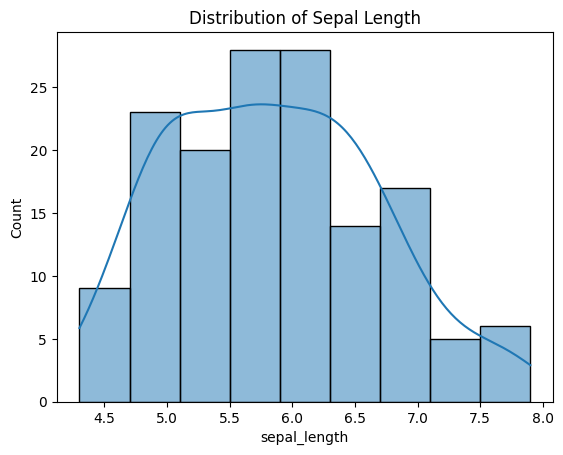

In [4]:
from scipy.stats import skew, kurtosis
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/iris.csv"
df = pd.read_csv(url)

feature = df["sepal_length"]
print("Skewness: ", skew(feature))
print("Kurtosis: ", kurtosis(feature))

sns.histplot(feature, kde=True)
plt.title("Distribution of Sepal Length")
plt.show()

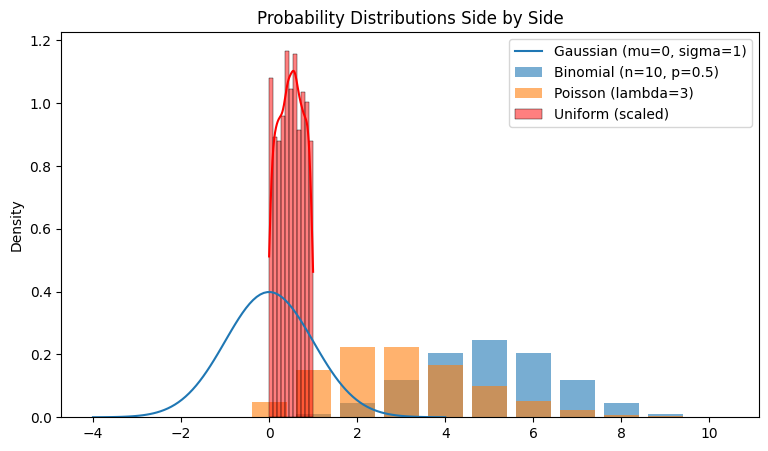

In [5]:
# Visual survey of the main distributions from Week 3, plus Uniform
from scipy.stats import norm, binom, poisson

fig, ax = plt.subplots(figsize=(9, 5))

x = np.linspace(-4, 4, 100)
ax.plot(x, norm.pdf(x, loc=0, scale=1), label="Gaussian (mu=0, sigma=1)")

n, p = 10, 0.5
x_b = np.arange(0, n + 1)
ax.bar(x_b, binom.pmf(x_b, n, p), alpha=0.6, label="Binomial (n=10, p=0.5)")

lam = 3
x_p = np.arange(0, 10)
ax.bar(x_p, poisson.pmf(x_p, lam), alpha=0.6, label="Poisson (lambda=3)")

uniform_samples = np.random.uniform(low=0, high=10, size=1000)
sns.histplot(uniform_samples / 10, kde=True, label="Uniform (scaled)", color="red", ax=ax, stat="density")

ax.set_title("Probability Distributions Side by Side")
ax.legend()
plt.show()

## Day 3 — Confidence Intervals: Z vs T Distribution

**What it covers:** Building a confidence interval around a sample mean, using the Z-distribution (large samples / known population std) vs the T-distribution (small samples / unknown population std).

**Why it matters for AI work:** Whenever you report a metric from a limited sample (e.g. "model accuracy: 87% on a 100-example test set"), a confidence interval tells you how much to trust that number. A single accuracy figure without an interval hides how uncertain it actually is, especially on small test sets.

**When to use what:**
- **Z-distribution** — large sample size (rule of thumb: n > 30) or you already know the true population standard deviation
- **T-distribution** — small sample size AND unknown population standard deviation (the more common real-world case). The t-distribution has "fatter tails" than the normal distribution, which widens the interval to account for the extra uncertainty of a small sample.

**Pitfalls:**
- Using the Z-distribution on a small sample **understates** your true uncertainty — the interval will look narrower (more confident) than it should be.
- `np.std(data, ddof=1)` — the `ddof=1` argument matters here. It computes the *sample* standard deviation (divides by n-1), which is what confidence interval formulas expect, not the *population* standard deviation (`ddof=0`, the NumPy default).


In [6]:
from scipy.stats import norm, t

# --- Z-based confidence interval (large sample, n=100) ---
np.random.seed(42)
data_large = np.random.normal(loc=50, scale=10, size=100)

mean = np.mean(data_large)
std = np.std(data_large, ddof=1)   # sample std, NOT population std
n = len(data_large)

z_value = norm.ppf(0.975)   # for a 95% CI: middle 95%, so 2.5% in each tail
margin_of_error = z_value * (std / np.sqrt(n))
ci_z = (mean - margin_of_error, mean + margin_of_error)

print("Sample Mean:", mean)
print("95% Confidence Interval (Z-based, large sample):", ci_z)

Sample Mean: 48.96153482605907
95% Confidence Interval (Z-based, large sample): (np.float64(47.18155741526743), np.float64(50.74151223685072))


In [7]:
# --- T-based confidence interval (small sample, n=7) ---
data_small = [12, 14, 15, 16, 17, 18, 19]

mean_small = np.mean(data_small)
std_small = np.std(data_small, ddof=1)
n_small = len(data_small)

t_value = t.ppf(0.975, df=n_small - 1)   # note: needs degrees of freedom (n-1)
margin_of_error_t = t_value * (std_small / np.sqrt(n_small))
ci_t = (mean_small - margin_of_error_t, mean_small + margin_of_error_t)

print("Sample Mean:", mean_small)
print("95% Confidence Interval (T-based, small sample):", ci_t)
print("\nNotice the t-value is larger than a z-value would be here -")
print("the t-distribution widens the interval to reflect extra uncertainty from the small sample.")

Sample Mean: 15.857142857142858
95% Confidence Interval (T-based, small sample): (np.float64(13.627991424548366), np.float64(18.08629428973735))

Notice the t-value is larger than a z-value would be here -
the t-distribution widens the interval to reflect extra uncertainty from the small sample.


In [8]:
# --- Same idea, applied to a real dataset sample ---
import pandas as pd

df_iris = pd.read_csv("https://raw.githubusercontent.com/mwaskom/seaborn-data/master/iris.csv")
sample = df_iris["sepal_length"].sample(30, random_state=42)

mean_s = sample.mean()
std_s = sample.std()   # pandas .std() uses ddof=1 by default, matching what we want here
n_s = len(sample)

z_value = norm.ppf(0.975)
margin_of_error_s = z_value * (std_s / np.sqrt(n_s))
ci_s = (mean_s - margin_of_error_s, mean_s + margin_of_error_s)

print("Sample Mean (sepal_length, n=30):", mean_s)
print("95% Confidence Interval:", ci_s)

Sample Mean (sepal_length, n=30): 5.98
95% Confidence Interval: (np.float64(5.677616880642557), np.float64(6.282383119357444))


## Day 4 — Hypothesis Testing: One-Sample and Two-Sample T-Tests

**What it covers:** Testing whether a sample mean differs from a known/assumed value (one-sample t-test), and whether two independent groups differ from each other (two-sample t-test) — same test as Week 3 Day 6, applied more deliberately with explicit null hypotheses.

**Why it matters for AI work:** This is the formal version of "is Model A actually better than Model B" or "did this feature change actually shift the average value." Framing it as a null hypothesis test forces you to be explicit about what you're testing, rather than eyeballing two numbers and guessing.

**The hypothesis testing recipe (applies to every test this week):**
1. State the null hypothesis (H0) — usually "no difference" or "no effect"
2. Pick a significance level (alpha), conventionally 0.05
3. Run the test, get a p-value
4. If `p-value <= alpha`: reject H0 (the effect looks real). Otherwise: fail to reject H0 (not enough evidence of an effect)

**Pitfalls:**
- "Fail to reject H0" does **not** mean "H0 is true" — it means you don't have strong enough evidence against it. Absence of evidence isn't evidence of absence, especially with a small sample.
- Running many t-tests on the same data increases the chance that *something* looks "significant" purely by chance (multiple comparisons problem) — a real risk if you go testing every column pair in a dataset.


In [9]:
from scipy.stats import ttest_1samp, ttest_ind

# --- One-sample t-test: does this sample's mean differ from an assumed value? ---
data = [12, 14, 15, 16, 17, 18, 19]
population_mean = 15   # H0: the true mean is 15

t_stat, p_value = ttest_1samp(data, population_mean)
print("One-Sample T-Test - T-Statistic:", t_stat, " P-Value:", p_value)

alpha = 0.05
if p_value <= alpha:
    print("Reject the null hypothesis: significant difference from 15")
else:
    print("Fail to reject the null hypothesis: no significant difference from 15")

One-Sample T-Test - T-Statistic: 0.9408750722807707  P-Value: 0.38308824158668686
Fail to reject the null hypothesis: no significant difference from 15


In [10]:
# --- Two-sample t-test: do two independent groups differ? ---
group1 = [12, 14, 15, 16, 17, 18, 19]
group2 = [11, 13, 14, 15, 16, 17, 18]

t_stat, p_value = ttest_ind(group1, group2)
print("Two-Sample T-Test - T-Statistic:", t_stat, " P-Value:", p_value)

if p_value <= alpha:
    print("Reject the null hypothesis: significant difference between groups")
else:
    print("Fail to reject the null hypothesis: no significant difference between groups")

Two-Sample T-Test - T-Statistic: 0.7761823345023016  P-Value: 0.4526687398345261
Fail to reject the null hypothesis: no significant difference between groups


## Day 5 — More Hypothesis Tests: Paired T-Test, Chi-Square, and ANOVA

**What it covers:** Three more hypothesis tests, each for a different data situation: paired t-test (before/after on the same subjects), chi-square test (association between two categorical variables), and ANOVA (comparing 3+ group means at once).

**Why it matters for AI work:** Picking the *right* test for your data shape is the actual skill here — using the wrong one gives a technically-computed but meaningless p-value.

**When to use what:**
- **Paired t-test** (`ttest_rel`) — same subjects measured twice (before/after a treatment, model performance before/after a change on the *same* test cases). More statistical power than an unpaired test because it removes subject-to-subject variability.
- **Chi-square test** (`chi2_contingency`) — testing whether two **categorical** variables are associated (e.g. "is smoking status associated with time of day eaten out" — both are categories, not numbers)
- **ANOVA** (`f_oneway`) — comparing means across **3 or more** groups at once. Running pairwise t-tests instead (group1 vs group2, group1 vs group3, group2 vs group3) inflates your false-positive risk — ANOVA avoids that by testing all groups together in one test.

**Pitfalls:**
- ANOVA tells you "at least one group differs" — it does NOT tell you *which* group. You need a follow-up ("post-hoc") test like Tukey's HSD to find out which specific pairs differ.
- Chi-square requires reasonably sized expected frequencies in each cell of the table (rule of thumb: at least 5) — with very small or sparse categorical data, the test becomes unreliable.


In [11]:
from scipy.stats import ttest_1samp, ttest_ind, ttest_rel

# Paired t-test - same subjects, measured twice
pre_test = [12, 14, 15, 16, 17]
post_test = [13, 14, 16, 17, 18]
t_stat, p_value = ttest_rel(pre_test, post_test)
print("Paired T-Test - T-Statistic:", t_stat, " P-Value:", p_value)

Paired T-Test - T-Statistic: -3.9999999999999996  P-Value: 0.016130089900092553


In [12]:
# Chi-square test - association between two categorical variables
from scipy.stats import chi2_contingency

# Contingency table: e.g. rows = 2 groups, columns = 3 categories of an outcome
data = [[50, 30, 20], [30, 40, 30]]

chi2, p, dof, expected = chi2_contingency(data)
print("Chi-Square Statistic:", chi2)
print("P-Value:", p)
print("Expected Frequencies (if there were NO association):\n", expected)

Chi-Square Statistic: 8.428571428571429
P-Value: 0.01478287719483942
Expected Frequencies (if there were NO association):
 [[40. 35. 25.]
 [40. 35. 25.]]


In [13]:
# ANOVA - comparing 3+ group means at once
from scipy.stats import f_oneway

group1 = [10, 12, 14, 16, 18]
group2 = [9, 11, 13, 15, 17]
group3 = [8, 10, 12, 14, 16]

f_stat, p_value = f_oneway(group1, group2, group3)
print("F-Statistic:", f_stat)
print("P-Value:", p_value)

if p_value <= 0.05:
    print("At least one group mean differs significantly (ANOVA doesn't say which one).")
else:
    print("No significant difference detected among the group means.")

F-Statistic: 0.5
P-Value: 0.6186248513251715
No significant difference detected among the group means.


## Day 6 — Your First Real ML Model: Linear Regression with scikit-learn

**What it covers:** Fitting a linear regression using `sklearn.linear_model.LinearRegression` — the library version of what you built from scratch in Week 3 Day 7. Also: reading a correlation heatmap to sanity-check which features might be useful predictors before modeling.

**Why it matters for AI work:** This is the moment the course shifts from "understanding the math" to "using the tools." Every scikit-learn model you'll touch for the rest of the course follows this exact same three-line pattern: `model = SomeModel()`, `model.fit(X, y)`, `model.predict(X_new)`. Learning this pattern once means you already know 80% of how to use any new sklearn model.

**Reading the output:**
- `model.coef_` — the slope(s): how much `y` changes per 1-unit increase in each feature
- `model.intercept_` — the predicted `y` when all features are 0
- `model.score(X, y)` — R², same meaning as Week 3 Day 7 (proportion of variance explained)

**Pitfalls:**
- `X` must be 2D for scikit-learn (shape `(n_samples, n_features)`), even for a single feature — hence `.reshape(-1, 1)`. Passing a 1D array raises a `ValueError`. This trips up almost everyone the first time.
- A high correlation on a heatmap suggests a *linear* relationship — it can completely miss strong *non-linear* relationships. Always look at a scatter plot too, not just the correlation number.
- `model.score(X, y)` here is evaluated on the **same data the model was trained on** — again, no train/test split yet (Week 5 fixes this). Treat this R² as "how well it fits what it's seen," not "how well it'll generalize."


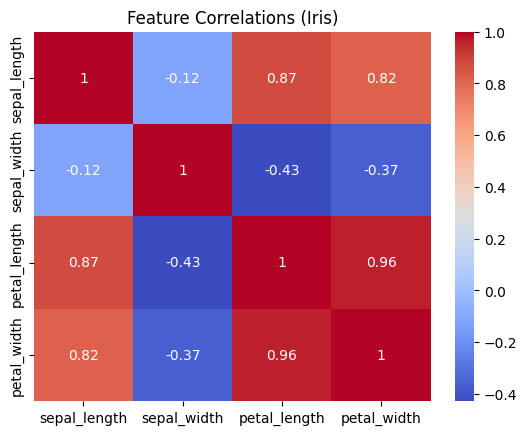

In [14]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/iris.csv"
df = pd.read_csv(url)

numeric_df = df.drop(columns=["species"])
correlation_matrix = numeric_df.corr()

sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm")
plt.title("Feature Correlations (Iris)")
plt.show()

In [15]:
from sklearn.linear_model import LinearRegression

# Toy example first, to see exactly what fit() produces
x_toy = np.array([1, 2, 3, 4, 5]).reshape(-1, 1)   # sklearn needs 2D input, even for 1 feature
y_toy = np.array([2, 4, 5, 8, 10])

model = LinearRegression()
model.fit(x_toy, y_toy)

print("Slope: ", model.coef_[0])
print("Intercept: ", model.intercept_)
print("R-Squared: ", model.score(x_toy, y_toy))

Slope:  2.0
Intercept:  -0.20000000000000018
R-Squared:  0.9803921568627451


Slope: 2.908 (true value: 3)
Intercept: 0.430 (true value: ~0)
R-squared: 0.958


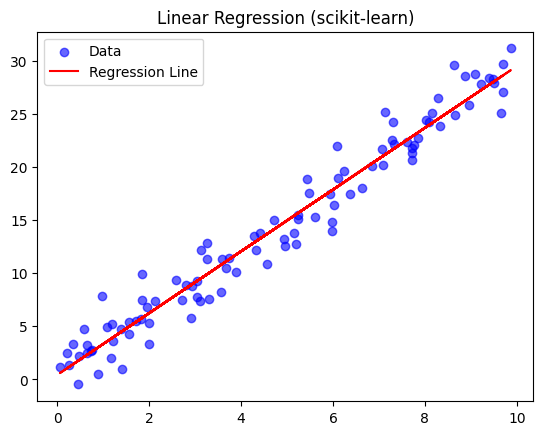

In [16]:
# Realistic example: synthetic data with noise, then visualize the fit
np.random.seed(42)
x = np.random.rand(100, 1) * 10
y = 3 * x + np.random.randn(100, 1) * 2   # true relationship: y = 3x + noise

model = LinearRegression()
model.fit(x, y)

slope = model.coef_[0][0]
intercept = model.intercept_[0]
r_squared = model.score(x, y)
print(f"Slope: {slope:.3f} (true value: 3)")
print(f"Intercept: {intercept:.3f} (true value: ~0)")
print(f"R-squared: {r_squared:.3f}")

plt.scatter(x, y, color="blue", alpha=0.6, label="Data")
plt.plot(x, model.predict(x), color="red", label="Regression Line")
plt.legend()
plt.title("Linear Regression (scikit-learn)")
plt.show()

## Day 7 — Mini Project: Full Analysis Pipeline on Restaurant Tips Data

**What it covers:** Combining the whole week into one realistic analysis: load real data → inspect → visualize distribution → test for association between categorical variables (chi-square) → test for a difference between groups (t-test) → fit and visualize a regression model. This mirrors a real "explain this dataset" task.

**Dataset:** the classic `tips` dataset — restaurant bills, tips, and info about the table (day, time, smoker status, party size, gender of the bill-payer).

**The questions this pipeline answers, in order:**
1. What does the data look like? (inspect + visualize)
2. Are `smoker` status and `time of day` related? (chi-square — both are categorical)
3. Do male and female bill-payers tip differently? (t-test — comparing two group means)
4. Can we predict tip amount from the total bill? (linear regression)

**Pitfalls:**
- `del df["sex"]` etc. would delete columns needed for the group comparisons — if you're inspecting correlations on numeric columns only, drop non-numeric columns into a *separate* variable rather than deleting them from the original DataFrame you still need.
- The regression at the end only uses `total_bill` as a predictor — real tipping behavior is also affected by `size` (party size), `day`, and `smoker` status. A single-feature model here is a starting point, not the full picture — Week 5+ covers using multiple features together.


In [17]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency, ttest_ind
from sklearn.linear_model import LinearRegression

url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/tips.csv"
df = pd.read_csv(url)

# Step 1: Inspect
df.info()
print(df.describe())

<class 'pandas.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   total_bill  244 non-null    float64
 1   tip         244 non-null    float64
 2   sex         244 non-null    str    
 3   smoker      244 non-null    str    
 4   day         244 non-null    str    
 5   time        244 non-null    str    
 6   size        244 non-null    int64  
dtypes: float64(2), int64(1), str(4)
memory usage: 13.5 KB


       total_bill         tip        size
count  244.000000  244.000000  244.000000
mean    19.785943    2.998279    2.569672
std      8.902412    1.383638    0.951100
min      3.070000    1.000000    1.000000
25%     13.347500    2.000000    2.000000
50%     17.795000    2.900000    2.000000
75%     24.127500    3.562500    3.000000
max     50.810000   10.000000    6.000000


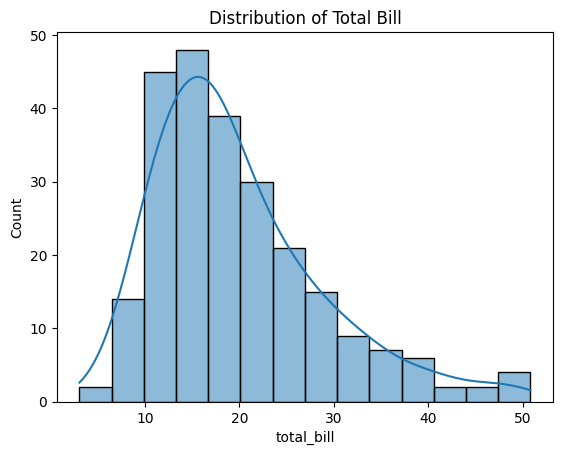

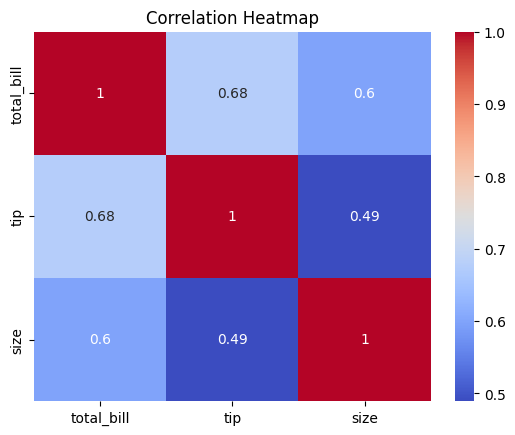

In [18]:
# Step 2: Visualize
sns.histplot(df["total_bill"], kde=True)
plt.title("Distribution of Total Bill")
plt.show()

numeric_only = df.select_dtypes(include=[np.number])   # keep original df intact, just select numeric cols for corr()
sns.heatmap(numeric_only.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [19]:
# Step 3: Chi-square test - are smoker status and time of day associated?
contingency_table = pd.crosstab(df["smoker"], df["time"])
print("Contingency Table:\n", contingency_table)

chi2, p, dof, expected = chi2_contingency(contingency_table)
print("\nChi-Square Statistic:", chi2)
print("P-Value:", p)

alpha = 0.05
if p <= alpha:
    print("Reject the null hypothesis: smoker status and time of day are associated")
else:
    print("Fail to reject the null hypothesis: no detected association")

Contingency Table:
 time    Dinner  Lunch
smoker               
No         106     45
Yes         70     23

Chi-Square Statistic: 0.5053733928754354
P-Value: 0.4771485672079724
Fail to reject the null hypothesis: no detected association


In [20]:
# Step 4: T-test - do male and female bill-payers tip differently?
male_tips = df[df["sex"] == "Male"]["tip"]
female_tips = df[df["sex"] == "Female"]["tip"]

t_stat, p_value = ttest_ind(male_tips, female_tips)
print("T-Statistic: ", t_stat)
print("P-Value: ", p_value)

if p_value <= alpha:
    print("Reject the null hypothesis: significant difference in tipping by gender")
else:
    print("Fail to reject the null hypothesis: no significant difference detected")

T-Statistic:  1.387859705421269
P-Value:  0.16645623503456755
Fail to reject the null hypothesis: no significant difference detected


Slope:  0.10502451738435337
Intercept:  0.9202696135546731
R-Squared: 0.45661658635167657


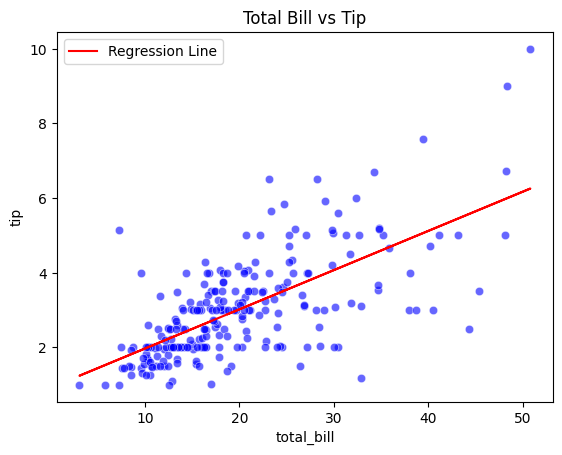

In [21]:
# Step 5: Linear regression - predicting tip from total bill
X = df["total_bill"].values.reshape(-1, 1)
y = df["tip"].values

model = LinearRegression()
model.fit(X, y)

print("Slope: ", model.coef_[0])
print("Intercept: ", model.intercept_)
print("R-Squared:", model.score(X, y))

sns.scatterplot(x=df["total_bill"], y=df["tip"], color="blue", alpha=0.6)
plt.plot(df["total_bill"], model.predict(X), color="red", label="Regression Line")
plt.title("Total Bill vs Tip")
plt.legend()
plt.show()

## Week 4 Recap

| Day | Topic | Where you'll use it again |
|---|---|---|
| 1 | Random variables, PMF/PDF | Simulation, Monte Carlo methods |
| 2 | Skewness, kurtosis | Deciding whether to transform features before modeling |
| 3 | Confidence intervals (Z vs T) | Reporting model metrics honestly |
| 4 | One/two-sample t-tests | Comparing model versions or A/B test results |
| 5 | Paired t-test, chi-square, ANOVA | Picking the right test for categorical vs numeric, 2 vs 3+ groups |
| 6 | First scikit-learn model | The `fit()`/`predict()` pattern used by every sklearn model |
| 7 | Full analysis pipeline | The realistic shape of "explain this dataset" work |

**Before moving to Week 5:** you should be comfortable choosing the *right* statistical test for a given data situation (categorical vs numeric, 2 groups vs 3+, paired vs independent) — that judgment call matters more than memorizing any single formula. Week 5 moves into the proper ML workflow: train/test splits, and classification models beyond simple regression.
